# **Approach 2:** Group products using image processing and vectorizing existing fields

## Tasks 1 & 2: Match identical/variant products

In this second approach, we process the images provided for each product and create an embedding for the image. We also use existing features (`brand`, `color`, `shoeType`, `product_name`) and create the corresponding embeddings. All embeddings were created using the **TF-IDF vectorizer**. Using those embeddings we find the similarities among different products and we cluster using **DBSCAN**. We tried several parameters to check which work best. We evaluate the clusters created using **Silhouette score** (unsupervised) and on the sample (supervised).

In this approach we don't separate into task 1 and task 2 because the process is identical in both tasks. The only difference is the choice of parameters that give the best performance on each task. As mentioned earlier, we can only evaluate (and therefore identify the best performing parameters for) **Task 2**.

As an evaluation metric we use the **Micro-average precision** because we have class imbalance. Micro-average accounts for class imbalance by treating each instance equally (instead of treating every class equally). In this way we aim to **minimize the total of False Positives** (i.e. the total of misgrouped products).

Our algorithms are **evaluated** on a manually labeled sample dataset. The labels correspond to variant groupings, which means that **only Task 2 can currently be evaluated**. However, Task 1 could be evaluated in a similar manner, provided we have a sample dataset labeled specifically for that task.

In [1]:
!pip install -qq torchvision
!pip install -qq hdbscan
!pip install -qq rapidfuzz

In [2]:
# Import libraries
from IPython.display import display, HTML
from PIL import Image
from collections import Counter, defaultdict
from io import BytesIO
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import pair_confusion_matrix, silhouette_score
from sklearn.metrics.cluster import pair_confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.preprocessing import OneHotEncoder, normalize
from tqdm import tqdm
import hdbscan
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import requests
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from itertools import count
from sklearn.cluster import DBSCAN

### Function to visualize products images

In [3]:
# Function to visualize clusters as HTML with an optional max_products limit
def show_clusters_as_html(df, cluster_ids, max_products=None):
    for cluster_id in cluster_ids:
        cluster_df = df[df['cluster_label'] == cluster_id]
        if cluster_df.empty:
            print(f"Cluster {cluster_id} is empty!")
            continue

        if max_products is not None:
            cluster_df = cluster_df.head(max_products)

        html = f"<h3 style='margin-top:20px'>Cluster {cluster_id} ({len(cluster_df)} items)</h3>"
        html += "<div style='display:flex;flex-wrap:wrap'>"

        for _, row in cluster_df.iterrows():
            name = row.get('product_name', '')
            
            # Choose the best available image
            for col in [
                'mainImage.original_url',
                'secondary_image_1.original_url',
                'secondary_image_2.original_url',
                'secondary_image_3.original_url'
            ]:
                img = row.get(col, '')
                if isinstance(img, str) and img.startswith('http'):
                    break
            else:
                img = ''
            
            html += f"""
                <div style='margin:10px;text-align:center'>
                    <img src='{img}' width='120' style='border-radius:8px'><br>
                    <div style='max-width:120px;font-size:12px'>{name}</div>
                </div>
            """
        html += "</div>"
        display(HTML(html))

### Create separate dataframes

In [4]:
# Load the JSON file
with open('sneakers_sample_19062025.txt', 'r', encoding='utf-8') as f:    # added encoding = utf8 otherwise: decoding error
    raw_data = json.load(f)

# Create separate dataframes
meta_rows = []
data_rows = []
sources_rows = []

# Exclude some fields that are not necessary for our tasks
exclude_fields = {
    'creation_date', 'update_date',
    'validation', 'synchronization',
    'catalogs', 'selling_authorization', "product_urls"
}

for entry in raw_data:
    # Top-level fields
    meta = {
        key: entry[key] for key in entry
        if key not in exclude_fields and key not in ['data', 'sources']
    }
    meta_rows.append(meta)
    
    # Extract nested fields (if they exist)
    if 'data' in entry:
        data_rows.append(entry['data'])
    if 'sources' in entry and isinstance(entry['sources'], list):
        for source in entry['sources']:
            # Optionally, attach product ID to track back
            source['mirakl_product_id'] = entry.get('mirakl_product_id')
            sources_rows.append(source)

# Convert all parts to DataFrames
df_meta = pd.DataFrame(meta_rows)
df_data = pd.json_normalize(data_rows)
df_sources = pd.DataFrame(sources_rows)

# Preview
print("Meta columns:", df_meta.columns.tolist())
print("Data columns:", df_data.columns.tolist())
print("Sources sample:", df_sources.head())

Meta columns: ['mirakl_product_id', 'product_sku', 'data_origin']
Data columns: ['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription']
Sources sample:   provider_code                               provider_sku  \
0          2077        1071A091-101--EUM-18--WHITE / BLACK   
1          2002                   VN0A3MTJT2J1--417--BLACK   
2          2167                                IH6003-44.5   
3          207

We observe that `data_origin` column is nested.

In [5]:
# Flatten 'data_origin' column
data_origin_df = pd.json_normalize(df_meta['data_origin'])

# Add prefixes so we know where they came from
data_origin_df = data_origin_df.add_prefix('origin_')

# Drop original nested columns from df_meta
df_meta = df_meta.drop(columns=['data_origin'])

# Merge the flattened parts back
df_meta = pd.concat([df_meta, data_origin_df], axis=1)

In [6]:
# Load the sample to evaluate the groups
sample_df = pd.read_csv("sample.csv")

### **Approach 2:** Group products using image processing and vectorizing existing fields

In [7]:
# extract the image URL and store it in a new column named "image_url"
df = pd.read_json('sneakers_sample_19062025.txt', lines=False)
df["image_url"] = df["data"].apply(lambda x: x.get("mainImage", {}).get("source") or x.get("mainImage", {}).get("original_url"))

In [8]:
df.head()

,data,mirakl_product_id,creation_date,update_date,product_sku,validation,synchronization,catalogs,product_urls,sources,selling_authorization,data_origin,image_url
0,"{'EAN': [], 'size': '44', 'brand': 'ASICS', 'c...",d96975c5-0bea-41f6-a4a8-fdac53f374f3,2024-01-09T12:09:20.568Z,2024-11-06T13:03:01.469Z,d96975c5-0bea-41f6-a4a8-fdac53f374f3,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2077', 'provider_sku': '10...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",https://media-prod-eu-1.mirakl.net/SOURCE/0b6a...
1,"{'EAN': [], 'size': '44', 'brand': 'VANS', 'co...",6f302b78-9a86-484e-894f-bb39220931a3,2023-11-09T13:08:33.276Z,2025-02-12T12:21:44.083Z,6f302b78-9a86-484e-894f-bb39220931a3,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2002', 'provider_sku': 'VN...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",https://media-prod-eu-1.mirakl.net/SOURCE/acb3...
2,"{'EAN': [], 'size': '44.5', 'brand': 'ADIDAS',...",70006973-aa9f-4176-9f38-0ba2c5a1b06f,2025-03-29T08:43:47.421Z,2025-03-30T21:07:23.464Z,70006973-aa9f-4176-9f38-0ba2c5a1b06f,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2167', 'provider_sku': 'IH...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",https://media-prod-eu-1.mirakl.net/SOURCE/a618...
3,"{'EAN': [], 'size': '42', 'brand': 'NIKE', 'co...",6b010b1d-7475-44dc-ad56-502769d2e742,2024-01-04T12:29:59.343Z,2024-11-06T13:00:53.470Z,6b010b1d-7475-44dc-ad56-502769d2e742,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2077', 'provider_sku': 'CT...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",https://media-prod-eu-1.mirakl.net/SOURCE/14fc...
4,"{'EAN': [], 'size': '11/EU 46', 'brand': 'PUMA...",cf04d217-bfd6-4743-ae4b-bc98712959ca,2025-02-13T14:31:57.524Z,2025-03-01T00:03:24.205Z,cf04d217-bfd6-4743-ae4b-bc98712959ca,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '3390', 'provider_sku': '46...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi...",https://media-prod-eu-1.mirakl.net/SOURCE/e101...


### Image Embeddings

(no need to run the following cells again, we load the embeddings and similarity matrix)

In [9]:
# # Load model (no classifier head)
# # Loading ResNet50 (pretrained on ImageNet)
# # Removing the final classification layer (so we get image features instead of class probabilities)
# # Sets the model to evaluation mode (.eval())
# device = torch.device("cpu")
# model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# model = torch.nn.Sequential(*list(model.children())[:-1])
# model.eval()

# # Preprocessing
# # Resize images to 224x224 and converting to tensor
# # Normalizing using ImageNet mean & std (required for pretrained models)
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# # Define all fallback image columns, many products have multiple image sources
# # The code tries each of these in order until it finds one that works
# fallback_cols = [
#     'mainImage.original_url',
#     'secondary_image_1.original_url',
#     'secondary_image_2.original_url',
#     'secondary_image_3.original_url'
# ]

# # Initialize storage
# image_features = [] # To store embeddings
# image_ids = [] # To track product ID for each image
# broken_image_rows = [] # Log failed attempts

# # Loop through df_data, one product per row
# for idx, row in df_data.iterrows():
#     success = False
#     last_url_attempted = None

#     # Try each of the 4 image columns one by one, and skip if the URL is missing or invalid.
#     for col in fallback_cols:
#         url = row.get(col)
#         if not isinstance(url, str) or not url.startswith('http'):
#             continue

#         last_url_attempted = url

#         try:
#             response = requests.get(url, timeout=15)

#             # Downloading the image with a timeout.
#             # Rejecting the result if it's HTML pretending to be an image (Avoid 404 HTML pretending to be a JPG )
#             if response.status_code != 200 or b'<html' in response.content[:100].lower():
#                 raise ValueError("HTML or bad status")

#             # Try to open as image, loading the image as RGB.
#             # Applying the transform and sends it to the model.
#             # Extracting a 2048-d feature vector for each image.
#             img = Image.open(BytesIO(response.content)).convert('RGB')
#             img_tensor = transform(img).unsqueeze(0).to(device)

#             with torch.no_grad():
#                 features = model(img_tensor).squeeze().numpy()

#             # If image processed successfully, storing its vector and ID.
#             # If it failed, moving to the next fallback column.
#             image_features.append(features)
#             image_ids.append(row.get('mirakl_product_id', f"row_{idx}"))

#             print(f"Row {idx}: Loaded image from '{col}'")
#             success = True
#             break  # Stop after first success

#         except Exception as e:
#             print(f"Row {idx}: ❌ '{col}' failed: {e}")
            
#     # If none of the fallback columns worked, logging the row index and last attempted URL.
#     if not success:
#         broken_image_rows.append({
#             'row_idx': idx,
#             'product_id': row.get('mirakl_product_id'),
#             'last_attempted_url': last_url_attempted
#         })
#         print(f"Row {idx}: ❌ All fallbacks failed.")

# # Saving broken image info for review, all failures to a CSV so we can check and maybe repair them later
# pd.DataFrame(broken_image_rows).to_csv("broken_images.csv", index=False)

# # cosine similarity on valid image embeddings, converting list of feature vectors to NumPy array
# # (Calculating cosine similarity between every pair of images)
# image_features = np.array(image_features)
# image_sim_matrix = cosine_similarity(image_features)

# # image_sim_matrix[i, j] = similarity between image i and j

In [10]:
# url = df_data.loc[85, 'mainImage.original_url']
# r = requests.get(url)
# print("Status:", r.status_code)
# print("Type:", r.headers.get("Content-Type"))

# # trying to display raw content if not a valid image
# try:
#     img = Image.open(BytesIO(r.content))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.show()
# except Exception as e:
#     print("PIL error:", e)
#     print("Raw content (first 300 chars):", r.content[:300])

In [11]:
# url = df_data.loc[8, 'mainImage.original_url']
# r = requests.get(url)

# print("Status Code:", r.status_code)
# print("Content-Type:", r.headers.get("Content-Type"))
# print("First 300 chars of response:")
# print(r.text[:300])  # to show if it's HTML or an error page

In [12]:
# # Save embeddings and corresponding IDs
# np.save("image_features.npy", image_features)
# pd.Series(image_ids).to_csv("image_ids.csv", index=False)

In [13]:
# load the image embeddings
image_features = np.load("image_features.npy")
image_ids = pd.read_csv("image_ids.csv").iloc[:, 0].tolist()

In [14]:
# Compute the cosine similarity matrix between all product image embeddings
image_sim_matrix = cosine_similarity(image_features)

In [15]:
image_sim_matrix.shape

(5679, 5679)

In [16]:
image_features.shape

(5679, 2048)

From the total of 5823 products, 5679 have at least one valid image URL. Each image embedding has length 2048.

In [17]:
# Build DataFrame for image embeddings and valid metadata
image_df = pd.DataFrame({
    'image_id': image_ids,
    'features': list(image_features)
})

# Create reverse mapping from 'row_i' fallback to real row index
image_df['row_idx'] = image_df['image_id'].apply(
    lambda x: int(x.split('_')[1]) if isinstance(x, str) and x.startswith('row_') else -1)

# Get metadata rows for valid images
df_filtered = []
for i, row in image_df.iterrows():
    if row['row_idx'] >= 0:
        meta = df_data.iloc[row['row_idx']].copy()
    else:
        meta = df_data[df_data['task1_approach1'] == row['image_id']].iloc[0].copy()
    df_filtered.append(meta)

# Convert back to DataFrame
df_filtered = pd.DataFrame(df_filtered).reset_index(drop=True)

# Update image features matrix
image_features = np.stack(image_df['features'].to_numpy())

In [18]:
image_df.head()

,image_id,features,row_idx
0,row_0,"[0.0, 0.0, 0.0, 0.0, 0.021618342, 0.0, 0.0, 0....",0
1,row_1,"[0.0, 0.0, 0.014974779, 0.039054606, 0.2362951...",1
2,row_3,"[0.0, 0.0, 0.037595145, 0.1022926, 0.14256164,...",3
3,row_4,"[0.0, 0.0, 0.0, 0.0, 0.14014705, 0.0, 0.0, 0.0...",4
4,row_5,"[0.0, 0.0, 0.01151118, 0.0, 0.5357198, 0.0, 0....",5


`filtered_df` only has the rows for which the products have at least one valid image. `image_df` includes the embedding for each image and the corresponding index (mirakle id was used for indexing).

In [19]:
print(df_data.columns.tolist())

['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription']


In [20]:
print(df_meta.columns.tolist())

['mirakl_product_id', 'product_sku', 'origin_name [en_GB].origin', 'origin_name [en_GB].provider_code', 'origin_name [el_CY].origin', 'origin_name [el_CY].provider_code', 'origin_color.origin', 'origin_color.provider_code', 'origin_shortDescription [el_CY].origin', 'origin_shortDescription [el_CY].provider_code', 'origin_secondary_image_2.origin', 'origin_secondary_image_2.provider_code', 'origin_secondary_image_1.origin', 'origin_secondary_image_1.provider_code', 'origin_shortDescription [en_GB].origin', 'origin_shortDescription [en_GB].provider_code', 'origin_secondary_image_3.origin', 'origin_secondary_image_3.provider_code', 'origin_mainImage.origin', 'origin_mainImage.provider_code', 'origin_returnable.origin', 'origin_size.origin', 'origin_size.provider_code', 'origin_refinementColor.origin', 'origin_category.origin', 'origin_category.provider_code', 'origin_updateOnDelta.origin', 'origin_brand.origin', 'origin_brand.provider_code', 'origin_returnable.provider_code', 'origin_long

In [21]:
print(df_sources.columns.tolist())

['provider_code', 'provider_sku', 'mirakl_product_id']


In [22]:
df_filtered.shape #correclty includes only the rows of df_data that have a valid image

(5679, 33)

### Attribute embeddings

Using only the products with valid images we create the embeddings the features:

In [23]:
# Structured features
structured_features = df_filtered[['brand', 'color', 'shoeType']].fillna('').astype(str).agg(' '.join, axis=1)
structured_vec = TfidfVectorizer().fit_transform(structured_features)
structured_sim_matrix = cosine_similarity(structured_vec)

# Text sim subset (use only valid ones)
df_filtered['product_name'] = df_filtered['name [en_GB]'].fillna('').astype(str)
tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(df_filtered['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# Combine all
combined_sim = (
    0.4 * text_sim_matrix +                       
    0.5 * cosine_similarity(image_features) +      
    0.1 * structured_sim_matrix)

In [24]:
structured_sim_matrix.shape

(5679, 5679)

In [25]:
# fix potential overflows and negatives
combined_sim = np.clip(combined_sim, 0, 1)
combined_dist = 1 - combined_sim

# DBSCAN clustering with eps = 0.5
clustering = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
labels = clustering.fit_predict(combined_dist)

# Store results
df_filtered['approach2'] = labels

In [26]:
df_filtered['approach2'].unique()

array([ 0,  1, -1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19], dtype=int64)

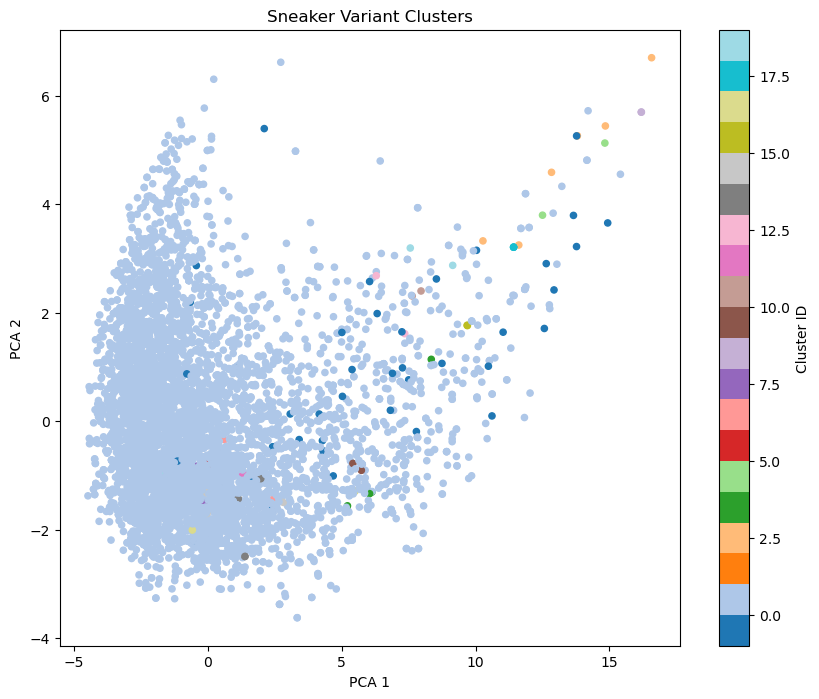

In [27]:
# Reduce similarity to distance
distance_matrix = 1 - combined_sim

# Use PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(distance_matrix)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_filtered['approach2'], cmap='tab20', s=20)
plt.title("Sneaker Variant Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster ID")
plt.show()

### **Evaluate clustering for eps = 0.5**

Compute **Silhouette score**:

In [28]:
# extract labels
labels = df_filtered['approach2'].to_numpy()

# Remove noise points (products that have not been clustered)
mask = labels != -1

# Ensure diagonal is zero for silhouette computation
np.fill_diagonal(combined_dist, 0)

if mask.sum() > 1:
    score = silhouette_score(combined_dist[mask][:, mask], labels[mask], metric='precomputed')
    print("Silhouette Score (no noise):", round(score, 4))
else:
    print("Not enough clustered points to compute silhouette score.")

Silhouette Score (no noise): -0.049


Not a good clustering. Now evaluate using a labeled sample of the dataset:

Evaluate on **labeled sample**:

In [29]:
sample_df.columns

Index(['EAN', 'size', 'brand', 'color', 'category', 'heelType', 'shoeType',
       'shoeWidth', 'heelHeight', 'returnable', 'name [el_CY]', 'name [en_GB]',
       'updateOnDelta', 'refinementColor', 'variantGroupCode',
       'jiniusSkuMatchCode', 'longDescription [el_CY]',
       'shortDescription [en_GB]', 'mainImage.source',
       'mainImage.original_url', 'shortDescription [el_CY]',
       'secondary_image_1.source', 'secondary_image_1.original_url',
       'secondary_image_2.source', 'secondary_image_2.original_url',
       'secondary_image_3.source', 'secondary_image_3.original_url',
       'longDescription [en_GB]', 'fashionMaterial', 'name', 'longDescription',
       'shortDescription', 'mirakl_product_id', 'group_id1', 'name [en_GB',
       'group_id2', 'final_group_id', 'final_group_id_clip_strict',
       'manual_group_id', 'manual_group_name'],
      dtype='object')

In [30]:
sample_df['manual_group_id'].value_counts()

manual_group_id
148.0    14
233.0    11
7.0      10
88.0      9
25.0      8
         ..
352.0     1
91.0      1
2.0       1
92.0      1
609.0     1
Name: count, Length: 609, dtype: int64

In [31]:
# Load CLIP image embeddings of the sample
clip_embeddings = np.load("clip_embeddings.npy")

# Load product IDs of the sample
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Step 1: Structured features
structured_features = sample_df[['brand', 'color', 'shoeType']].fillna('').astype(str).agg(' '.join, axis=1)
structured_vec = TfidfVectorizer().fit_transform(structured_features)
structured_sim_matrix = cosine_similarity(structured_vec)

# Step 2: Text similarity from product name
sample_df['product_name'] = sample_df['name [en_GB]'].fillna('').astype(str)
tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(sample_df['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# Step 3: Load and align image features
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Ensure alignment between sample_df and clip_embeddings
# Step 3a: Create index mapping
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Step 3b: Filter invalid ones (just in case)
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()

# Step 3c: Subset the image features
image_features_subset = clip_embeddings[sample_indices]
image_sim_matrix = cosine_similarity(image_features_subset)

# Step 4: Combine similarities
combined_sim = (
    0.4 * text_sim_matrix +
    0.5 * image_sim_matrix +
    0.1 * structured_sim_matrix
)
combined_sim = np.clip(combined_sim, 0, 1)
combined_dist = 1 - combined_sim

# Step 5: DBSCAN
clustering = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
labels = clustering.fit_predict(combined_dist)

# Step 6: Store result
sample_df['sample_group_id'] = labels

In [32]:
# Compute the pairwise confusion matrix
conf_matrix = pair_confusion_matrix(sample_df['manual_group_id'], sample_df['sample_group_id'])

TP = conf_matrix[1, 1]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TN = conf_matrix[0, 0]

# Micro-average precision
micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

# Micro-average accuracy (pairwise)
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")

Micro-average Precision: 0.0017
Micro-average Accuracy: 0.0433


**Not a good performance. We should try other parameter settings.**

Save the groups created: (no need to run this again)

In [33]:
# # Merge merchant info
# merchant_map = df_sources.set_index("mirakl_product_id")["provider_code"].to_dict()

# # Cleaned JSON
# variant_groups = {}
# for group_id in df_filtered["approach2"].unique():
#     if group_id == -1:
#         continue  # skip noise
#     group = df_filtered[df_filtered["approach2"] == group_id]
#     first = group.iloc[0]
#     group_json = {
#         "model_name": first["product_name"],
#         "brand": first["brand"],
#         "variants": [],
#         "offers": []
#     }
#     seen = set()
#     for _, row in group.iterrows():
#         variant_key = (row["color"], row["size"])
#         if variant_key not in seen:
#             seen.add(variant_key)
#             group_json["variants"].append({
#                 "color": row["color"],
#                 "size": row["size"],
#                 "image": row.get("mainImage.original_url", ""),
#                 "task1_approach1": row["task1_approach1"]
#             })
#         group_json["offers"].append({
#             "merchant": merchant_map.get(row["task1_approach1"], "unknown"),
#             "product_sku": row.get("product_sku", ""),
#             "task1_approach1": row["task1_approach1"]
#         })
#     variant_groups[str(group_id)] = group_json

# # Save result
# with open("variant_groups_cleaned.json", "w") as f:
#     json.dump(variant_groups, f, indent=2)

In [34]:
with open("variant_groups.json", "r") as f:
    data = json.load(f)

# Preview the first group
first_key = list(data.keys())[0]
print(json.dumps(data[first_key], indent=2))

{
  "model_name": "Gel-rocket 11 mens volleyball/indoor shoes",
  "brand": "ASICS",
  "variants": [
    {
      "color": "White / Black",
      "size": "44",
      "image": "https://administrator.athlokinisi.com.cy/product_catalog/groups/162995/1071a091-101.jpg",
      "product_group_id": 1041.0
    },
    {
      "color": "Black",
      "size": "44",
      "image": "https://privesports.com.cy/product_catalog/groups/66610/vn0a3mtjt2j1-black.jpg",
      "product_group_id": 4423.0
    },
    {
      "color": NaN,
      "size": "44.5",
      "image": "https://jinius-prod.mirakl.net/mmp/media/product-media/34383/IH6003-1.jpg",
      "product_group_id": NaN
    },
    {
      "color": "White / Black / Volt",
      "size": "42",
      "image": "https://administrator.athlokinisi.com.cy/product_catalog/groups/164557/ct2927-100.jpg",
      "product_group_id": 2839.0
    },
    {
      "color": "Black/white",
      "size": "11/EU 46",
      "image": "https://s3.gy.digital/famousports/uploads/ass

### Try to find a better clustering

**Try other similarity weights**

In [35]:
def try_similarity_weights(text_sim, image_sim, structured_sim, df, eps=0.5, min_samples=2):
    best_config = None
    results = []
    for text_w in [0.2, 0.3, 0.4]:
        for img_w in [0.4, 0.5, 0.6]:
            struc_w = 1.0 - text_w - img_w
            if struc_w < 0: continue
            combined_sim = (
                text_w * text_sim +
                img_w * image_sim +
                struc_w * structured_sim
            )
            combined_sim = np.clip(combined_sim, 0, 1)
            dist = 1 - combined_sim
            labels = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed').fit_predict(dist)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = sum(labels == -1)
            results.append((text_w, img_w, struc_w, n_clusters, n_noise))
            print(f"Text: {text_w:.1f}, Image: {img_w:.1f}, Structured: {struc_w:.1f} => Clusters: {n_clusters}, Noise: {n_noise}")
    return results

In [36]:
try_similarity_weights(text_sim_matrix, image_sim_matrix, structured_sim_matrix, df_filtered)

Text: 0.2, Image: 0.4, Structured: 0.4 => Clusters: 9, Noise: 20
Text: 0.2, Image: 0.5, Structured: 0.3 => Clusters: 1, Noise: 5
Text: 0.2, Image: 0.6, Structured: 0.2 => Clusters: 1, Noise: 0
Text: 0.3, Image: 0.4, Structured: 0.3 => Clusters: 14, Noise: 25
Text: 0.3, Image: 0.5, Structured: 0.2 => Clusters: 1, Noise: 6
Text: 0.3, Image: 0.6, Structured: 0.1 => Clusters: 1, Noise: 0
Text: 0.4, Image: 0.4, Structured: 0.2 => Clusters: 20, Noise: 41
Text: 0.4, Image: 0.5, Structured: 0.1 => Clusters: 5, Noise: 12
Text: 0.4, Image: 0.6, Structured: 0.0 => Clusters: 1, Noise: 0


[(0.2, 0.4, 0.4, 9, 20),
 (0.2, 0.5, 0.30000000000000004, 1, 5),
 (0.2, 0.6, 0.20000000000000007, 1, 0),
 (0.3, 0.4, 0.29999999999999993, 14, 25),
 (0.3, 0.5, 0.19999999999999996, 1, 6),
 (0.3, 0.6, 0.09999999999999998, 1, 0),
 (0.4, 0.4, 0.19999999999999996, 20, 41),
 (0.4, 0.5, 0.09999999999999998, 5, 12),
 (0.4, 0.6, 0.0, 1, 0)]

In [37]:
print("text_sim_matrix shape:", text_sim_matrix.shape)
print("image_sim_matrix shape:", image_sim_matrix.shape)
print("structured_sim_matrix shape:", structured_sim_matrix.shape)

text_sim_matrix shape: (947, 947)
image_sim_matrix shape: (947, 947)
structured_sim_matrix shape: (947, 947)


### **Evaluate for the above weight combinations and eps = 0.5**

In [38]:
results = []

for text_w in [0.2, 0.3, 0.4]:
    for img_w in [0.4, 0.5, 0.6]:
        struc_w = 1.0 - text_w - img_w
        if struc_w < 0:
            continue

        # Combine similarities
        combined_sim = (
            text_w * text_sim_matrix +
            img_w * image_sim_matrix +
            struc_w * structured_sim_matrix
        )
        combined_sim = np.clip(combined_sim, 0, 1)
        combined_dist = 1 - combined_sim

        # DBSCAN clustering
        clustering = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
        labels = clustering.fit_predict(combined_dist)

        # Evaluate against manual_group_id
        conf_matrix = pair_confusion_matrix(sample_df['manual_group_id'], labels)
        TP = conf_matrix[1, 1]
        FP = conf_matrix[0, 1]
        FN = conf_matrix[1, 0]
        TN = conf_matrix[0, 0]

        micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

        results.append({
            'text_w': text_w,
            'img_w': img_w,
            'struc_w': struc_w,
            'micro_precision': micro_precision,
            'micro_accuracy': micro_accuracy,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
            'n_noise': np.sum(np.array(labels) == -1)
        })

# Show results as a sorted DataFrame
results_df = pd.DataFrame(results).sort_values(by='micro_precision', ascending=False)
display(results_df) 

,text_w,img_w,struc_w,micro_precision,micro_accuracy,n_clusters,n_noise
6,0.4,0.4,0.2,0.002270,0.271073,20,41
3,0.3,0.4,0.3,0.002030,0.183372,14,25
0,0.2,0.4,0.4,0.001840,0.103958,9,20
7,0.4,0.5,0.1,0.001742,0.043328,5,12
4,0.3,0.5,0.2,0.001691,0.014275,1,6
1,0.2,0.5,0.3,0.001688,0.012185,1,5
2,0.2,0.6,0.2,0.001670,0.001670,1,0
5,0.3,0.6,0.1,0.001670,0.001670,1,0
8,0.4,0.6,0.0,0.001670,0.001670,1,0


We observe that none of the above combinations gives an acceptable micro-average precision. Following we explore multiple values for **eps** parameter and evaluate each clustering on the labeled sample.

### Try multiple eps values

In [39]:
image_features = np.load("image_features.npy")

# Structured similarity
structured_features = df_filtered[['brand', 'color', 'shoeType']].fillna('').astype(str).agg(' '.join, axis=1)
structured_vec = TfidfVectorizer().fit_transform(structured_features)
structured_sim_matrix = cosine_similarity(structured_vec)

# Text similarity
df_filtered['product_name'] = df_filtered['name [en_GB]'].fillna('').astype(str)
tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(df_filtered['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# Image similarity
image_sim_matrix = cosine_similarity(image_features)

# Combined similarity (fixed weights)
combined_sim = (
    0.4 * text_sim_matrix +
    0.5 * image_sim_matrix +
    0.1 * structured_sim_matrix
)
combined_sim = np.clip(combined_sim, 0, 1)
combined_dist = 1 - combined_sim

# --- Loop over different eps values ---
eps_values = [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3]
cluster_results = {}

for eps in eps_values:
    clustering = DBSCAN(eps=eps, min_samples=2, metric='precomputed')
    labels = clustering.fit_predict(combined_dist)

    # Store results in new column
    col_name = f'approach2_eps{str(eps).replace(".", "_")}'
    df_filtered[col_name] = labels

    # store summary stats
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(np.array(labels) == -1)
    cluster_results[eps] = {'n_clusters': n_clusters, 'n_noise': n_noise}

# Show summary
summary_df = pd.DataFrame.from_dict(cluster_results, orient='index').sort_index()
print(summary_df)

       n_clusters  n_noise
0.001         929     3636
0.002         929     3636
0.005         931     3627
0.010         941     3602
0.150        1003     1729
0.200         894     1285
0.250         760      946
0.300         600      665


### Evaluate on sample

In [40]:
# --- Step 1: Align image features to sample_df ---
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Keep only valid matches
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()
image_features_subset = clip_embeddings[sample_indices]

# --- Step 2: Similarity matrices ---

# Structured similarity
structured_features = sample_df[['brand', 'color', 'shoeType']].fillna('').astype(str).agg(' '.join, axis=1)
structured_vec = TfidfVectorizer().fit_transform(structured_features)
structured_sim_matrix = cosine_similarity(structured_vec)

# Text similarity
sample_df['product_name'] = sample_df['name [en_GB]'].fillna('').astype(str)
tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(sample_df['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# Image similarity
image_sim_matrix = cosine_similarity(image_features_subset)

# Combined similarity (fixed weights)
combined_sim = (
    0.4 * text_sim_matrix +
    0.5 * image_sim_matrix +
    0.1 * structured_sim_matrix
)
combined_sim = np.clip(combined_sim, 0, 1)
combined_dist = 1 - combined_sim

# --- Step 3: Loop over eps values and evaluate ---
eps_values = [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3]
results = []

for eps in eps_values:
    clustering = DBSCAN(eps=eps, min_samples=2, metric='precomputed')
    labels = clustering.fit_predict(combined_dist)

    # Compute micro-average precision & accuracy
    conf_matrix = pair_confusion_matrix(sample_df['manual_group_id'], labels)
    TP = conf_matrix[1, 1]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]
    TN = conf_matrix[0, 0]

    micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

    results.append({
        'eps': eps,
        'micro_precision': micro_precision,
        'micro_accuracy': micro_accuracy,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'n_noise': np.sum(np.array(labels) == -1)
    })

# Display results
results_df = pd.DataFrame(results).sort_values(by='micro_precision', ascending=False)
display(results_df)

,eps,micro_precision,micro_accuracy,n_clusters,n_noise
7,0.300,0.014372,0.898757,151,293
6,0.250,0.006849,0.808645,157,412
5,0.200,0.003798,0.706060,146,513
4,0.150,0.002631,0.589033,128,607
0,0.001,0.001631,0.114000,27,892
1,0.002,0.001631,0.114000,27,892
2,0.005,0.001631,0.114000,27,892
3,0.010,0.001629,0.119931,28,889


**Although micro-average accuracy is quite high, micro-average precision is still very low. This is due to accuracy considering also the TN and FN instances. Other approaches should be exlored.**

**Try additional eps values:**

In [41]:
#define possible values of eps parameter
eps_values = np.arange(0.01, 0.51, 0.01)

results = []

for eps in eps_values:
    print(f"\nRunning DBSCAN for eps = {eps}")

    # Fit DBSCAN
    model = DBSCAN(eps=eps, min_samples=2, metric='precomputed')
    labels = model.fit_predict(combined_dist)

    # Exclude noise
    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters < 2:
        #print(f"  Not enough clusters after noise filtering (n_clusters={n_clusters}). Skipping silhouette.")
        score = None
    else:
        # Compute silhouette (note: combined_dist is precomputed)
        np.fill_diagonal(combined_dist, 0)  # safety for silhouette_score
        try:
            score = silhouette_score(combined_dist[mask][:, mask], labels[mask], metric='precomputed')
            #print(f" Silhouette Score: {score:.4f}")
        except Exception as e:
            #print(f"  Error computing silhouette: {e}")
            score = None

    # Store results
    results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'silhouette_score': score,
        'noise_count': np.sum(labels == -1)
    })


Running DBSCAN for eps = 0.01

Running DBSCAN for eps = 0.02

Running DBSCAN for eps = 0.03

Running DBSCAN for eps = 0.04

Running DBSCAN for eps = 0.05

Running DBSCAN for eps = 0.060000000000000005

Running DBSCAN for eps = 0.06999999999999999

Running DBSCAN for eps = 0.08

Running DBSCAN for eps = 0.09

Running DBSCAN for eps = 0.09999999999999999

Running DBSCAN for eps = 0.11

Running DBSCAN for eps = 0.12

Running DBSCAN for eps = 0.13

Running DBSCAN for eps = 0.14

Running DBSCAN for eps = 0.15000000000000002

Running DBSCAN for eps = 0.16

Running DBSCAN for eps = 0.17

Running DBSCAN for eps = 0.18000000000000002

Running DBSCAN for eps = 0.19

Running DBSCAN for eps = 0.2

Running DBSCAN for eps = 0.21000000000000002

Running DBSCAN for eps = 0.22

Running DBSCAN for eps = 0.23

Running DBSCAN for eps = 0.24000000000000002

Running DBSCAN for eps = 0.25

Running DBSCAN for eps = 0.26

Running DBSCAN for eps = 0.27

Running DBSCAN for eps = 0.28

Running DBSCAN for eps = 0

In [42]:
#convert to dataframe for easier inspection
results_df = pd.DataFrame(results)
print(results_df)

     eps  n_clusters  silhouette_score  noise_count
0   0.01          28          0.998698          889
1   0.02          30          0.996469          885
2   0.03          33          0.980656          878
3   0.04          39          0.968567          864
4   0.05          45          0.943021          848
5   0.06          49          0.926639          834
6   0.07          59          0.899614          811
7   0.08          71          0.869475          783
8   0.09          83          0.844920          753
9   0.10          91          0.826481          730
10  0.11          98          0.805471          704
11  0.12         104          0.785698          679
12  0.13         117          0.762578          643
13  0.14         121          0.748148          630
14  0.15         128          0.733378          607
15  0.16         135          0.716053          586
16  0.17         138          0.701686          567
17  0.18         139          0.688664          550
18  0.19    

### Silhouette score

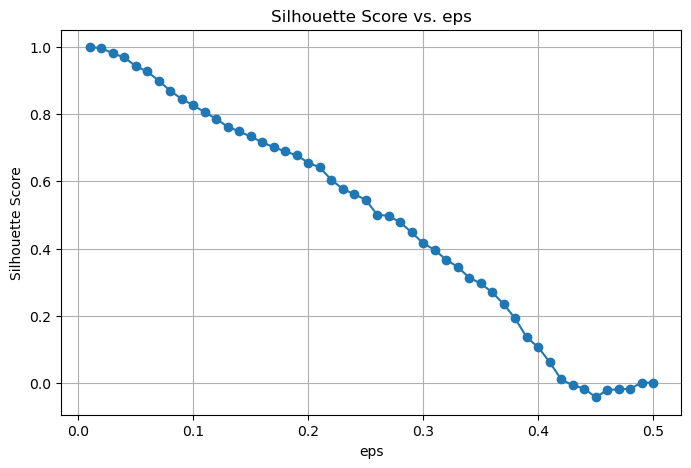

In [43]:
# plot Silhouette score vs eps
plt.figure(figsize=(8, 5))
plt.plot(results_df['eps'], results_df['silhouette_score'], marker='o')
plt.title('Silhouette Score vs. eps')
plt.xlabel('eps')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### Evaluate on sample

In [44]:
eps_values = np.arange(0.01, 0.51, 0.01)
y_true = sample_df['manual_group_id'].values

results = []

for eps in eps_values:
    print(f"Running DBSCAN for eps = {eps:.2f}")

    # Fit DBSCAN
    model = DBSCAN(eps=eps, min_samples=2, metric='precomputed')
    labels = model.fit_predict(combined_dist)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    # Evaluate only if enough clusters
    if n_clusters >= 1:
        try:
            conf_matrix = pair_confusion_matrix(y_true, labels)
            TP = conf_matrix[1, 1]
            FP = conf_matrix[0, 1]
            FN = conf_matrix[1, 0]
            TN = conf_matrix[0, 0]

            micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            micro_accuracy = (TP + TN) / (TP + FP + FN + TN)
        except Exception as e:
            micro_precision = None
            micro_accuracy = None
    else:
        micro_precision = None
        micro_accuracy = None

    results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'micro_precision': micro_precision,
        'micro_accuracy': micro_accuracy
    })

# Display results
results_df = pd.DataFrame(results).sort_values(by='micro_precision', ascending=False)
print(results_df)

Running DBSCAN for eps = 0.01
Running DBSCAN for eps = 0.02
Running DBSCAN for eps = 0.03
Running DBSCAN for eps = 0.04
Running DBSCAN for eps = 0.05
Running DBSCAN for eps = 0.06
Running DBSCAN for eps = 0.07
Running DBSCAN for eps = 0.08
Running DBSCAN for eps = 0.09
Running DBSCAN for eps = 0.10
Running DBSCAN for eps = 0.11
Running DBSCAN for eps = 0.12
Running DBSCAN for eps = 0.13
Running DBSCAN for eps = 0.14
Running DBSCAN for eps = 0.15
Running DBSCAN for eps = 0.16
Running DBSCAN for eps = 0.17
Running DBSCAN for eps = 0.18
Running DBSCAN for eps = 0.19
Running DBSCAN for eps = 0.20
Running DBSCAN for eps = 0.21
Running DBSCAN for eps = 0.22
Running DBSCAN for eps = 0.23
Running DBSCAN for eps = 0.24
Running DBSCAN for eps = 0.25
Running DBSCAN for eps = 0.26
Running DBSCAN for eps = 0.27
Running DBSCAN for eps = 0.28
Running DBSCAN for eps = 0.29
Running DBSCAN for eps = 0.30
Running DBSCAN for eps = 0.31
Running DBSCAN for eps = 0.32
Running DBSCAN for eps = 0.33
Running DB

Visualize the output for eps = 0.36 (highest micro-average precision).

In [45]:
# Step 1: Run DBSCAN for chosen_eps = 0.36
chosen_eps = 0.36
dbscan_model = DBSCAN(eps=chosen_eps, min_samples=2, metric='precomputed')
labels = dbscan_model.fit_predict(combined_dist)

# Step 2: Store labels in your DataFrame
sample_df['cluster_label'] = labels

# Step 3: Get the first 5 valid cluster IDs (excluding noise)
valid_clusters = sorted([cid for cid in set(labels) if cid != -1])[:5]

# Step 4: Show clusters using your function
show_clusters_as_html(sample_df, valid_clusters)

Clusters are too big, they include very different products. Terrible clustering.

### Alternative: HDBSCAN instead of DBSCAN

In [46]:
# Re-define HDBSCAN visual tuning function
def try_similarity_weights_hdbscan_with_visuals(text_sim, image_sim, structured_sim, df, min_cluster_size=3, min_samples=2):
    results = []
    for text_w in [0.2, 0.3, 0.4]:
        for img_w in [0.4, 0.5, 0.6]:
            struc_w = 1.0 - text_w - img_w
            if struc_w < 0:
                continue
            combined_sim = (
                text_w * text_sim +
                img_w * image_sim +
                struc_w * structured_sim
            )
            combined_sim = np.clip(combined_sim, 0, 1)
            combined_dist = 1 - combined_sim

            # Run HDBSCAN
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric='precomputed')
            labels = clusterer.fit_predict(combined_dist)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = sum(labels == -1)
            print(f"Text: {text_w:.1f}, Image: {img_w:.1f}, Structured: {struc_w:.1f} → Clusters: {n_clusters}, Noise: {n_noise}")

            # PCA for visualization
            pca = PCA(n_components=2)
            pca_features = pca.fit_transform(combined_sim)
            plt.figure(figsize=(6, 5))
            plt.scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab20', s=10)
            plt.title(f"HDBSCAN: T:{text_w}, I:{img_w}, S:{struc_w}\nClusters={n_clusters}, Noise={n_noise}")
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")
            plt.colorbar(label="Cluster ID")
            plt.tight_layout()
            plt.show()

            results.append({
                "text_weight": text_w,
                "image_weight": img_w,
                "structured_weight": struc_w,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "labels": labels
            })
    #return results

Text: 0.2, Image: 0.4, Structured: 0.4 → Clusters: 46, Noise: 302


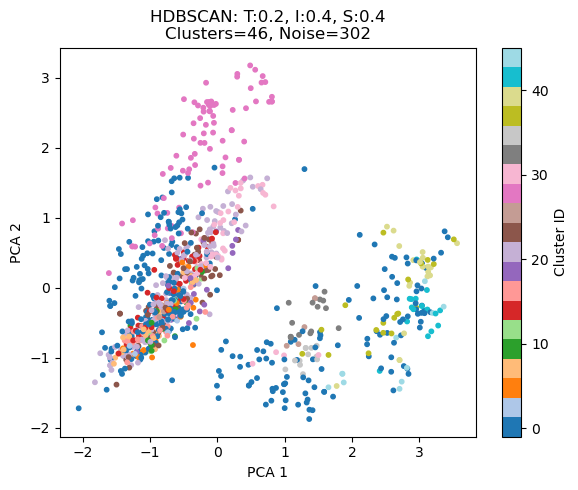

Text: 0.2, Image: 0.5, Structured: 0.3 → Clusters: 38, Noise: 311


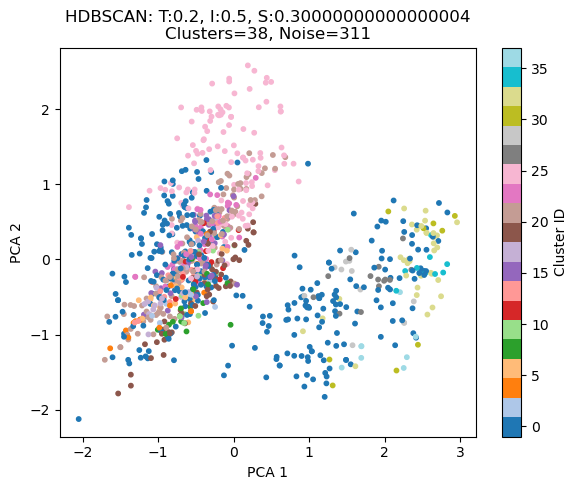

Text: 0.2, Image: 0.6, Structured: 0.2 → Clusters: 49, Noise: 317


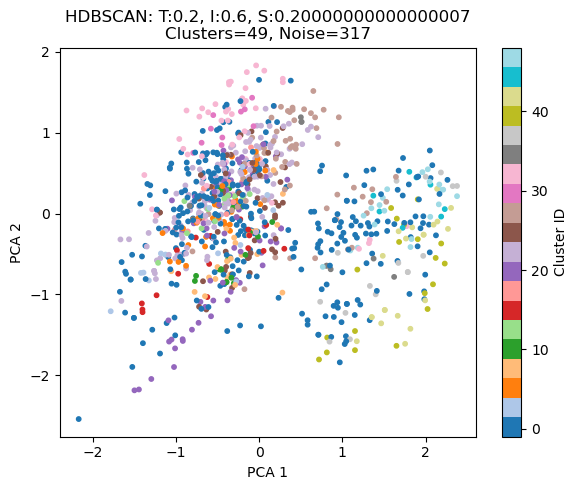

Text: 0.3, Image: 0.4, Structured: 0.3 → Clusters: 47, Noise: 329


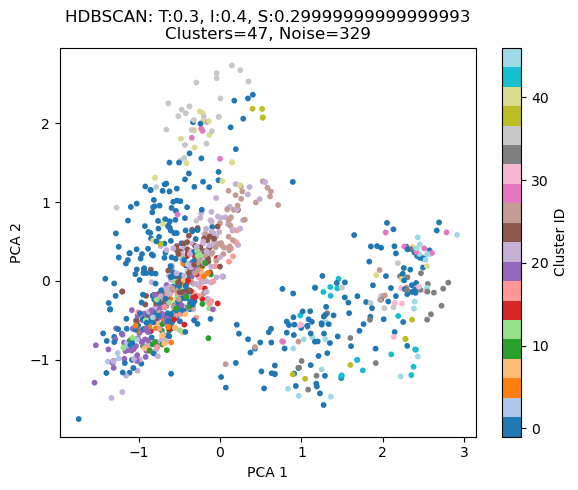

Text: 0.3, Image: 0.5, Structured: 0.2 → Clusters: 60, Noise: 368


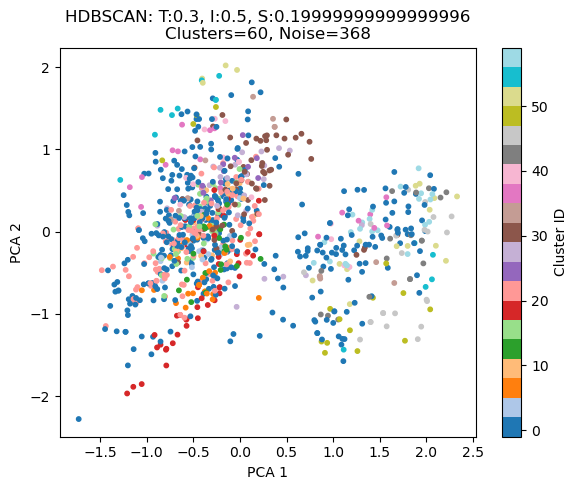

Text: 0.3, Image: 0.6, Structured: 0.1 → Clusters: 71, Noise: 362


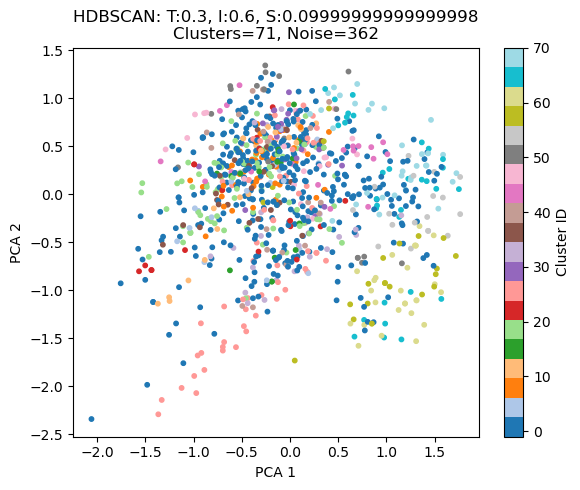

Text: 0.4, Image: 0.4, Structured: 0.2 → Clusters: 65, Noise: 356


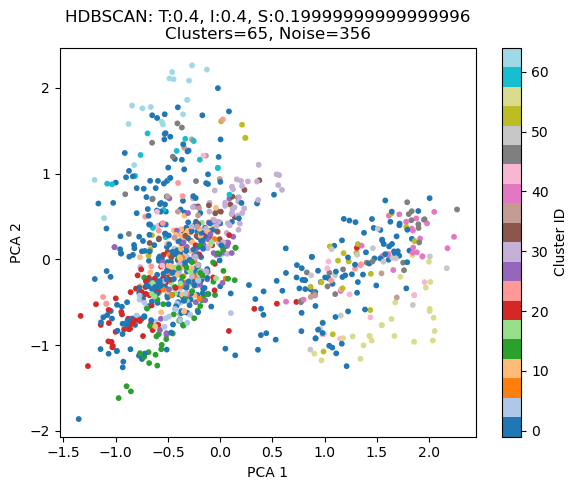

Text: 0.4, Image: 0.5, Structured: 0.1 → Clusters: 70, Noise: 380


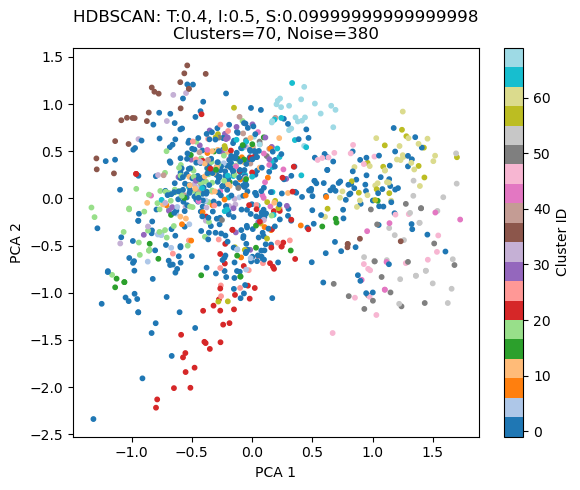

Text: 0.4, Image: 0.6, Structured: 0.0 → Clusters: 74, Noise: 433


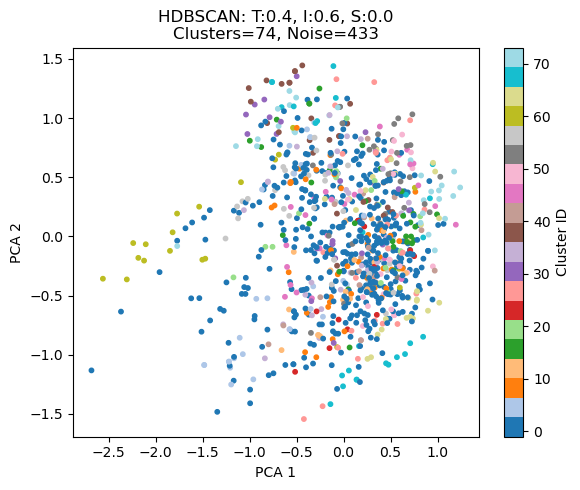

In [47]:
try_similarity_weights_hdbscan_with_visuals(
    text_sim_matrix,
    image_sim_matrix,
    structured_sim_matrix,
    df_filtered,
    min_cluster_size=4,
    min_samples=2)

### Evaluate on sample

In [48]:
results = []

# Set weights to loop over
text_weights = [0.2, 0.3, 0.4]
image_weights = [0.4, 0.5, 0.6]

# Manual labels
y_true = sample_df['manual_group_id'].values

for text_w in text_weights:
    for image_w in image_weights:
        struct_w = 1.0 - text_w - image_w
        if struct_w < 0:
            continue

        # Combine similarity matrices
        combined_sim = (
            text_w * text_sim_matrix +
            image_w * image_sim_matrix +
            struct_w * structured_sim_matrix
        )
        combined_sim = np.clip(combined_sim, 0, 1)
        combined_dist = 1 - combined_sim

        # Run HDBSCAN
        clusterer = hdbscan.HDBSCAN(min_cluster_size=4, min_samples=2, metric='precomputed')
        labels = clusterer.fit_predict(combined_dist)

        # Evaluate
        conf_matrix = pair_confusion_matrix(y_true, labels)
        TP = conf_matrix[1, 1]
        FP = conf_matrix[0, 1]
        FN = conf_matrix[1, 0]
        TN = conf_matrix[0, 0]

        micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        micro_accuracy = (TP + TN) / (TP + FP + FN + TN)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        results.append({
            'text_weight': text_w,
            'image_weight': image_w,
            'structured_weight': struct_w,
            'micro_precision': micro_precision,
            'micro_accuracy': micro_accuracy,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })

# Show results sorted by precision
results_df = pd.DataFrame(results).sort_values(by='micro_precision', ascending=False)
print(results_df)

   text_weight  image_weight  structured_weight  micro_precision  \
2          0.2           0.6                0.2         0.011026   
3          0.3           0.4                0.3         0.010327   
0          0.2           0.4                0.4         0.010086   
5          0.3           0.6                0.1         0.010024   
1          0.2           0.5                0.3         0.009887   
6          0.4           0.4                0.2         0.009864   
7          0.4           0.5                0.1         0.009473   
4          0.3           0.5                0.2         0.009089   
8          0.4           0.6                0.0         0.006704   

   micro_accuracy  n_clusters  n_noise  
2        0.869625          49      317  
3        0.860295          47      329  
0        0.874925          46      302  
5        0.845996          71      362  
1        0.866633          38      311  
6        0.847914          65      356  
7        0.832104          70   

### **Alternative**: Cluster using only the image embeddings

**Trying multiple eps values**

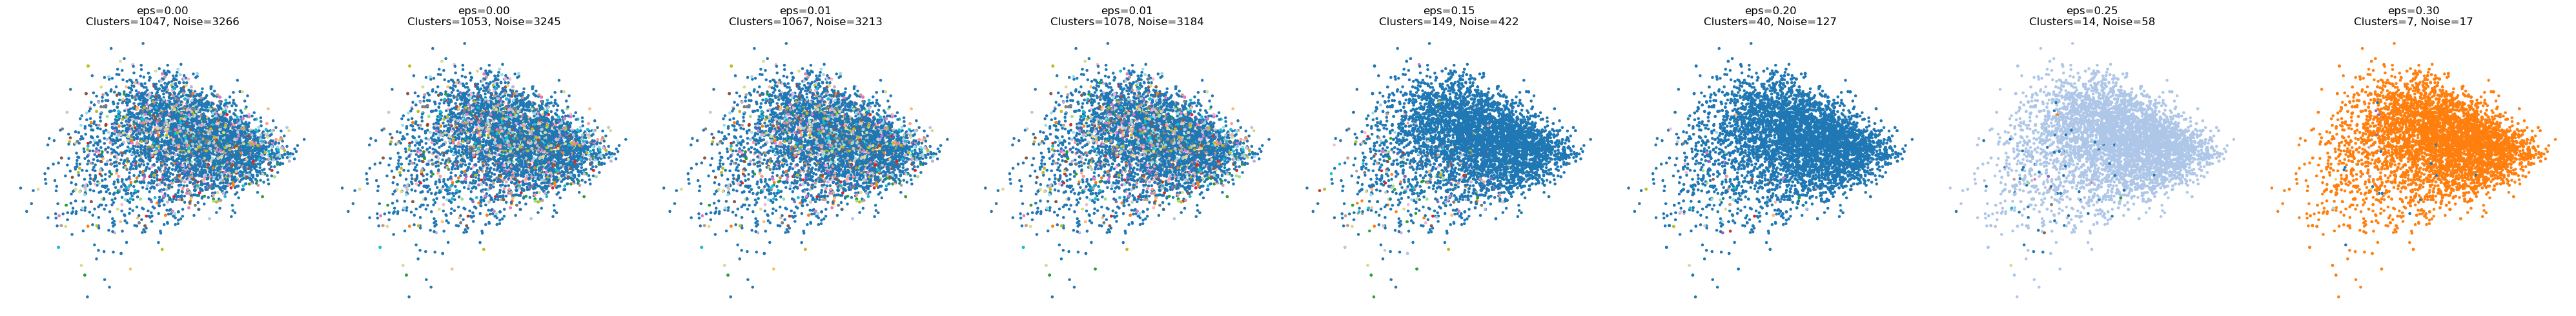

In [49]:
# Reduce dimensions using PCA for visualization
def reduce_with_pca(features, n_components=2):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(features)

# Run DBSCAN at multiple eps values, store results
def run_dbscan_varying_eps(image_features, eps_values):
    reduced_features = reduce_with_pca(image_features, n_components=2)
    all_results = []

    fig, axs = plt.subplots(1, len(eps_values), figsize=(5 * len(eps_values), 5))
    if len(eps_values) == 1:
        axs = [axs]

    for i, eps in enumerate(eps_values):
        db = DBSCAN(eps=eps, min_samples=2, metric='cosine')
        labels = db.fit_predict(image_features)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)

        axs[i].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='tab20', s=5)
        axs[i].set_title(f"eps={eps:.2f}\nClusters={n_clusters}, Noise={n_noise}")
        axs[i].axis('off')

        all_results.append({
            'eps': eps,
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })

    plt.tight_layout()
    plt.show()
    return all_results

image_features = np.load("image_features.npy")
results = run_dbscan_varying_eps(image_features, [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3])

For these clusterings we will compute the **Silhouette score**

In [50]:
#compute silhouette for the above clusterings
for res in results:
    labels = res['labels']
    eps = res['eps']
    mask = labels != -1

    if len(set(labels[mask])) < 2:
        print(f"eps={eps:.4f}: Only one cluster (or none) after removing noise. Cannot compute silhouette.")
        continue

    # Compute Silhouette Score using cosine distance on valid points only
    try:
        score = silhouette_score(
            image_features[mask], 
            labels[mask], 
            metric='cosine'
        )
        print(f"eps={eps:.4f}: Clusters={res['n_clusters']}, Noise={res['n_noise']}, Silhouette={score:.4f}")

    except Exception as e:
        print(f"eps={eps:.4f}: Error computing silhouette - {e}")

eps=0.0010: Clusters=1047, Noise=3266, Silhouette=0.9999
eps=0.0020: Clusters=1053, Noise=3245, Silhouette=0.9996
eps=0.0050: Clusters=1067, Noise=3213, Silhouette=0.9989
eps=0.0100: Clusters=1078, Noise=3184, Silhouette=0.9968
eps=0.1500: Clusters=149, Noise=422, Silhouette=-0.0884
eps=0.2000: Clusters=40, Noise=127, Silhouette=0.0816
eps=0.2500: Clusters=14, Noise=58, Silhouette=0.2422
eps=0.3000: Clusters=7, Noise=17, Silhouette=0.4852


We observe that lowering epsilon produces very high Silhouette scores (almost 1). However the noise is high, meaning that multiple products have not been grouped. Following we print the images of the products of a few clusters, for visual inspection and we evaluate on the annotated sample.

### **Evaluate on sample**

In [51]:
# Load CLIP image embeddings and product IDs
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Align embeddings to sample_df
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Filter valid entries
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()
image_features = clip_embeddings[sample_indices]
manual_group_ids = sample_df['manual_group_id'].values

# Eps values to try
eps_values = [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3]
results2 = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=2, metric='cosine')
    labels = db.fit_predict(image_features)

    # Pairwise micro-average precision & accuracy
    conf_matrix = pair_confusion_matrix(manual_group_ids, labels)
    TP = conf_matrix[1, 1]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]
    TN = conf_matrix[0, 0]

    micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

    results2.append({
        'eps': eps,
        'micro_precision': micro_precision,
        'micro_accuracy': micro_accuracy,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'n_noise': np.sum(np.array(labels) == -1)
    })

# Create and display result table
results2_df = pd.DataFrame(results2).sort_values(by='micro_precision', ascending=False)
print(results2_df)

     eps  micro_precision  micro_accuracy  n_clusters  n_noise
4  0.150         0.001708        0.026754           2       10
5  0.200         0.001673        0.003782           1        1
6  0.250         0.001670        0.001670           1        0
7  0.300         0.001670        0.001670           1        0
2  0.005         0.001628        0.155138          37      871
3  0.010         0.001628        0.155138          37      871
0  0.001         0.001626        0.151258          36      873
1  0.002         0.001626        0.151258          36      873


### Visualizing some clusters for inspection

In [52]:
# For a specific eps, print the images of some products in the same cluster, for visual inspection
target_eps = 0.001
result = next(res for res in results if abs(res['eps'] - target_eps) < 1e-6)

labels_eps = result['labels']
df_filtered['cluster_label'] = labels_eps

# Exclude noise (-1)
valid_clusters = sorted(c for c in set(labels_eps) if c != -1)

# Take first 5 clusters
selected_clusters = valid_clusters[:10]

print(f"Selected clusters for visualization: {selected_clusters}")

Selected clusters for visualization: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [53]:
# function to visualise these clusters as HTML
def show_clusters_as_html(df, cluster_ids):
    for cluster_id in cluster_ids:
        cluster_df = df[df['cluster_label'] == cluster_id]
        if cluster_df.empty:
            print(f"Cluster {cluster_id} is empty!")
            continue

        html = f"<h3 style='margin-top:20px'>Cluster {cluster_id} ({len(cluster_df)} items)</h3>"
        html += "<div style='display:flex;flex-wrap:wrap'>"

        for _, row in cluster_df.iterrows():
            name = row.get('product_name', '')
            
            # Choose the best available image
            for col in [
                'mainImage.original_url',
                'secondary_image_1.original_url',
                'secondary_image_2.original_url',
                'secondary_image_3.original_url'
            ]:
                img = row.get(col, '')
                if isinstance(img, str) and img.startswith('http'):
                    break
            else:
                img = ''
            
            html += f"""
                <div style='margin:10px;text-align:center'>
                    <img src='{img}' width='120' style='border-radius:8px'><br>
                    <div style='max-width:120px;font-size:12px'>{name}</div>
                </div>
            """
        html += "</div>"
        display(HTML(html))

In [54]:
show_clusters_as_html(df_filtered, selected_clusters)

From the images of the first 10 clusters, we observe that the products are indeed identical. As an additional inspection to check if the groups include different products, in the following code I extract the largest cluster that was created and print the images of its products:

In [55]:
#find the sizes of the clusters
non_noise = df_filtered[df_filtered['cluster_label'] != -1]
cluster_counts = non_noise['cluster_label'].value_counts()

print(cluster_counts)

biggest_cluster_label = cluster_counts.idxmax()
biggest_cluster_size = cluster_counts.max()

print(f"Biggest cluster label: {biggest_cluster_label}")
print(f"Size of biggest cluster: {biggest_cluster_size}")

cluster_label
547     7
9       7
495     6
670     6
510     6
       ..
392     2
393     2
394     2
395     2
1046    2
Name: count, Length: 1047, dtype: int64
Biggest cluster label: 547
Size of biggest cluster: 7


In [56]:
show_clusters_as_html(df_filtered, [biggest_cluster_label])

We observe that the products of the biggest cluster are indeed identical. However visual inspection is not an appropriate way to evaluate the clusterings (e.g. there might be multiple clusters that have *Adidas Campus 00s* which is not desirable) We also observe that some identical products have different names. 

### Alternative: Using PCA on images before clustering to reduce noise

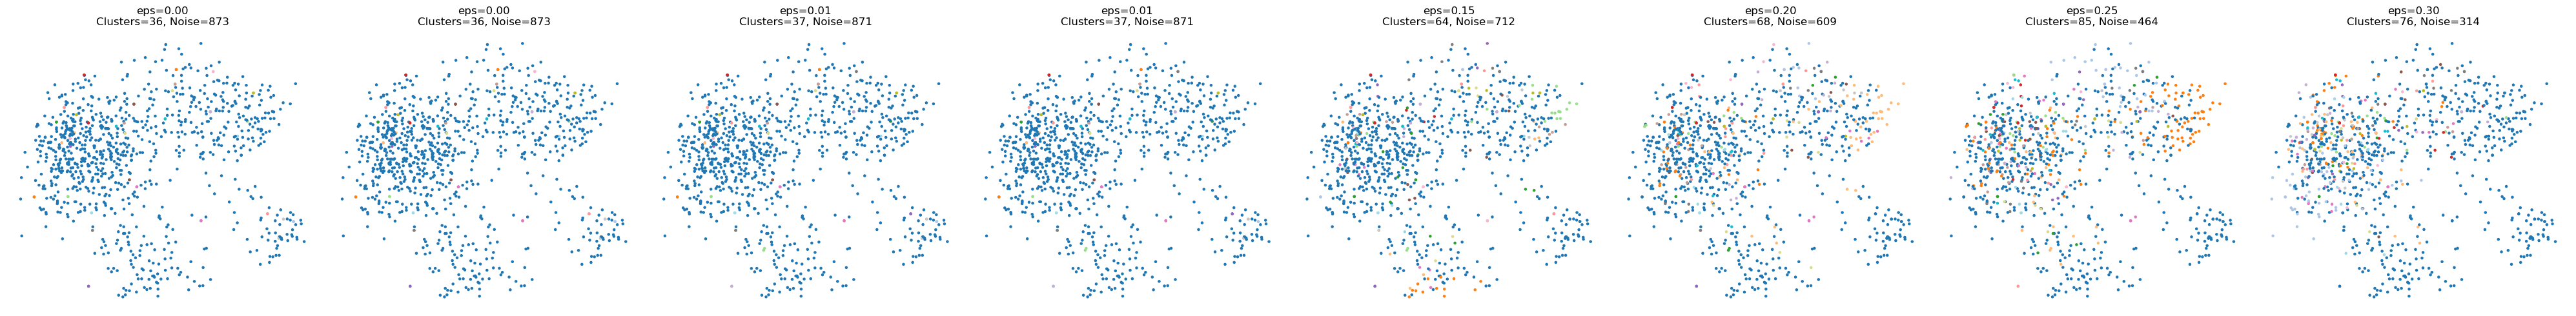

In [57]:
#same thing as before but using pca on images before dbscan to reduce noise
pca = PCA(n_components=50)
image_pca = pca.fit_transform(image_features)

# Reduce dimensions using PCA for visualization
def reduce_with_pca(features, n_components=2):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(features)

# Run DBSCAN at multiple eps values, store results but now on Images reduced using PCA!
def run_dbscan_varying_eps(image_features, eps_values):
    reduced_features = reduce_with_pca(image_features, n_components=2)
    all_results = []

    fig, axs = plt.subplots(1, len(eps_values), figsize=(5 * len(eps_values), 5))
    if len(eps_values) == 1:
        axs = [axs]

    for i, eps in enumerate(eps_values):
        db = DBSCAN(eps=eps, min_samples=2, metric='cosine')
        labels = db.fit_predict(image_features)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)

        axs[i].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='tab20', s=5)
        axs[i].set_title(f"eps={eps:.2f}\nClusters={n_clusters}, Noise={n_noise}")
        axs[i].axis('off')

        all_results.append({
            'eps': eps,
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })

    plt.tight_layout()
    plt.show()
    return all_results

# Example call (we must define image_features beforehand or load from .npy)
image_features = np.load("image_features.npy")
#eps_values = [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3] defined earlier
results = run_dbscan_varying_eps(image_pca, eps_values)

### **Evaluate on sample**

In [58]:
# Step 1: Load and align CLIP embeddings
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Align to sample_df using mirakl_product_id
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Filter valid entries
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()
image_features = clip_embeddings[sample_indices]

# Step 2: Reduce with PCA
pca = PCA(n_components=50)
image_pca = pca.fit_transform(image_features)

# Step 3: Get ground-truth groupings
manual_group_ids = sample_df['manual_group_id'].values

# Step 4: Run DBSCAN on PCA-reduced features for multiple eps values
#eps_values = [0.001, 0.002, 0.005, 0.01, 0.15, 0.2, 0.25, 0.3]
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=2, metric='cosine')
    labels = db.fit_predict(image_pca)

    # Evaluate with pair confusion matrix
    conf_matrix = pair_confusion_matrix(manual_group_ids, labels)
    TP = conf_matrix[1, 1]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]
    TN = conf_matrix[0, 0]

    micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

    results.append({
        'eps': eps,
        'micro_precision': micro_precision,
        'micro_accuracy': micro_accuracy,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'n_noise': np.sum(np.array(labels) == -1)
    })

# Step 5: Display results sorted by precision
results_df = pd.DataFrame(results).sort_values(by='micro_precision', ascending=False)
print(results_df)

     eps  micro_precision  micro_accuracy  n_clusters  n_noise
7  0.300         0.005126        0.789698          76      313
6  0.250         0.003611        0.737473          85      465
5  0.200         0.002356        0.573908          69      610
4  0.150         0.001894        0.430140          64      713
2  0.005         0.001628        0.155138          37      871
3  0.010         0.001628        0.155138          37      871
0  0.001         0.001626        0.151258          36      873
1  0.002         0.001626        0.151258          36      873


### Alternative: Attempting HDBSCAN instead of DBSCAN

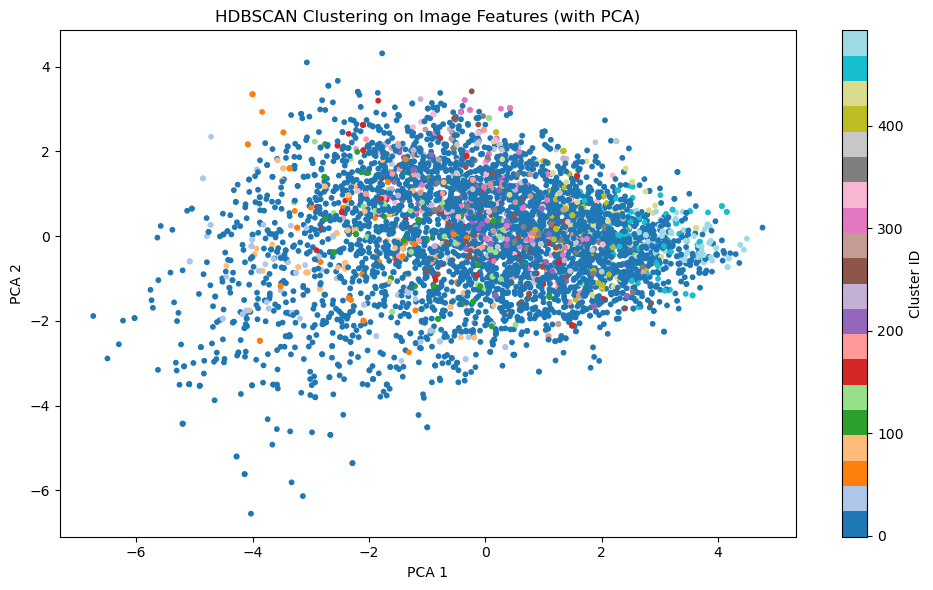

Clusters: 494, Noise Points: 3868


In [59]:
# Load image features
image_features = np.load("image_features.npy")  # adjust path as needed

# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=2, metric='euclidean')
labels = clusterer.fit_predict(image_features)

# PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(image_features)

# Plot clusters
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab20', s=10)
plt.title("HDBSCAN Clustering on Image Features (with PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()

# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = sum(labels == -1)
print(f"Clusters: {n_clusters}, Noise Points: {n_noise}")

We get more clusters which could be a good sign, still many noise points.

### **Evaluate on sample**

In [60]:
# Step 1: Load and align CLIP embeddings
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Align to sample_df
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Filter only valid entries
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()
image_features = clip_embeddings[sample_indices]
manual_group_ids = sample_df['manual_group_id'].values

# Step 2: HDBSCAN clustering on image features
clusterer = hdbscan.HDBSCAN(min_cluster_size=2, metric='euclidean')
labels = clusterer.fit_predict(image_features)

# Step 3: Evaluate clustering
conf_matrix = pair_confusion_matrix(manual_group_ids, labels)
TP = conf_matrix[1, 1]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TN = conf_matrix[0, 0]

micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

# Step 4: Save labels and summary
sample_df['hdbscan_labels'] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Clusters: {n_clusters}")
print(f"Noise Points: {n_noise}")
print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")

Clusters: 60
Noise Points: 603
Micro-average Precision: 0.0023
Micro-average Accuracy: 0.5841


Still very low micro-average precision.

We may also tune the alpha parameter, changing the weight of image versus metadata on the embeddings, in order to pick the best one. The following code could be applied later to more elegant solutions

In [61]:
# functions that tune alpha through (grid) and visualise the results of several values of it
def try_similarity_weights_hdbscan(text_sim, image_sim, structured_sim, df, min_cluster_size=3, min_samples=2):
    results = []
    for text_w in [0.2, 0.3, 0.4]:
        for img_w in [0.4, 0.5, 0.6]:
            struc_w = 1.0 - text_w - img_w
            if struc_w < 0:
                continue
            # Combine weighted similarity matrix
            combined_sim = (
                text_w * text_sim +
                img_w * image_sim +
                struc_w * structured_sim
            )
            combined_sim = np.clip(combined_sim, 0, 1)
            combined_dist = 1 - combined_sim

            # HDBSCAN requires a condensed or full distance matrix
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric='precomputed')
            labels = clusterer.fit_predict(combined_dist)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = sum(labels == -1)
            results.append((text_w, img_w, struc_w, n_clusters, n_noise))
            print(f"Text: {text_w:.1f}, Image: {img_w:.1f}, Structured: {struc_w:.1f} → Clusters: {n_clusters}, Noise: {n_noise}")
    return results